In [1]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

2.5.1+cu121
True
NVIDIA GeForce RTX 3050 Laptop GPU


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [3]:
device = torch.device("cuda")
print("Device:", device)

NUM_CLASSES = 10
BATCH_SIZE  = 32
NUM_EPOCHS  = 5
LR          = 3e-4
CLASSES = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']

Device: cuda


In [4]:
train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])
test_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

In [5]:
train_ds = datasets.CIFAR10('./data', train=True,  download=True, transform=train_tf)
test_ds  = datasets.CIFAR10('./data', train=False, download=True, transform=test_tf)
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
print(f"Train: {len(train_ds)} | Test: {len(test_ds)}")

Files already downloaded and verified


c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Files already downloaded and verified
Train: 50000 | Test: 10000


In [6]:
model = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
model.heads.head = nn.Linear(model.heads.head.in_features, NUM_CLASSES)
model = model.to(device)

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to C:\Users\User/.cache\torch\hub\checkpoints\vit_b_16-c867db91.pth
100.0%


In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

In [8]:
history = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}

for epoch in range(1, NUM_EPOCHS+1):
    model.train()
    tl, tc, tt = 0, 0, 0
    for imgs, labels in train_dl:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        tl += loss.item()
        tc += (out.argmax(1)==labels).sum().item()
        tt += len(labels)

    model.eval()
    vl, vc, vt = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in test_dl:
            imgs, labels = imgs.to(device), labels.to(device)
            out  = model(imgs)
            loss = criterion(out, labels)
            vl += loss.item()
            vc += (out.argmax(1)==labels).sum().item()
            vt += len(labels)

    scheduler.step()
    ta, va = tc/tt, vc/vt
    history['train_loss'].append(tl/len(train_dl))
    history['train_acc'].append(ta)
    history['val_loss'].append(vl/len(test_dl))
    history['val_acc'].append(va)
    print(f"Epoch {epoch}/{NUM_EPOCHS} | Train: {ta*100:.2f}% | Val: {va*100:.2f}%")

Epoch 1/5 | Train: 80.21% | Val: 86.75%
Epoch 2/5 | Train: 88.42% | Val: 90.74%
Epoch 3/5 | Train: 92.86% | Val: 92.61%
Epoch 4/5 | Train: 96.47% | Val: 94.41%
Epoch 5/5 | Train: 98.76% | Val: 96.05%


In [9]:
torch.save(model.state_dict(), "vit_cifar10.pth")
print("Model saqlandi!")

Model saqlandi!


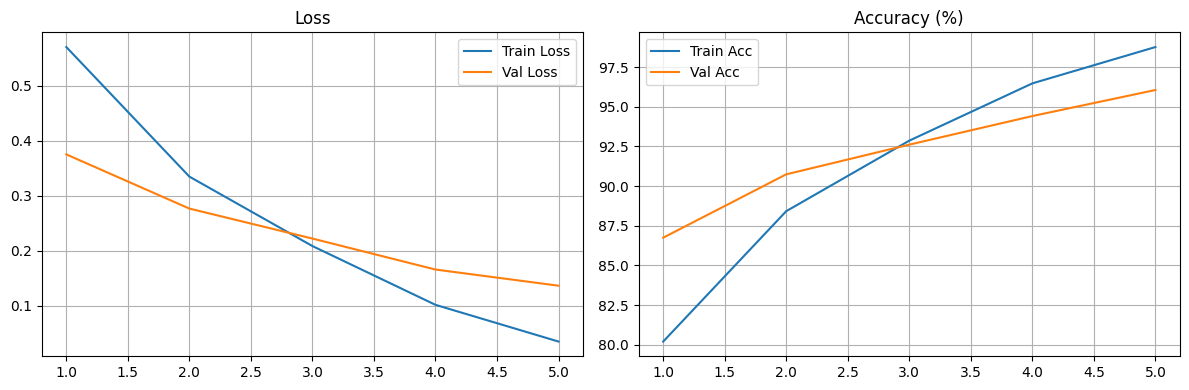

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
epochs = range(1, NUM_EPOCHS+1)
ax1.plot(epochs, history['train_loss'], label='Train Loss')
ax1.plot(epochs, history['val_loss'],   label='Val Loss')
ax1.set_title('Loss'); ax1.legend(); ax1.grid(True)
ax2.plot(epochs, [a*100 for a in history['train_acc']], label='Train Acc')
ax2.plot(epochs, [a*100 for a in history['val_acc']],   label='Val Acc')
ax2.set_title('Accuracy (%)'); ax2.legend(); ax2.grid(True)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=120)
plt.show()

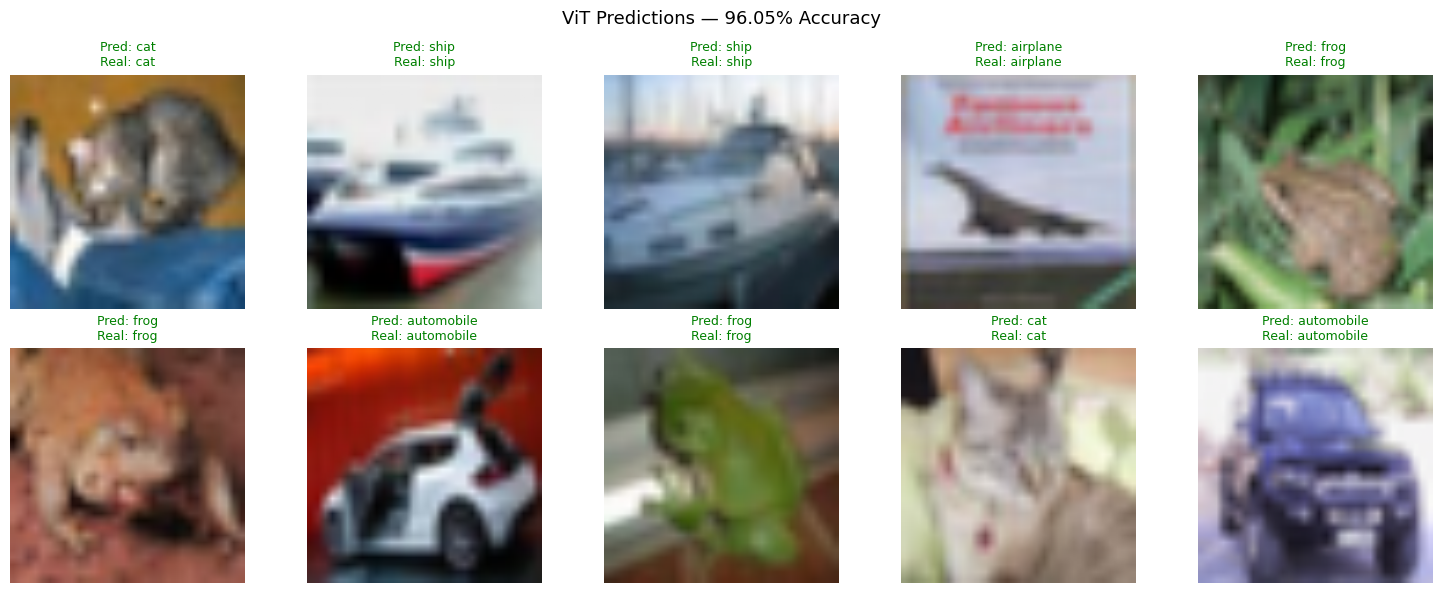

In [11]:
model.eval()
imgs, lbls = next(iter(test_dl))
with torch.no_grad():
    preds = model(imgs.to(device)).argmax(1).cpu()

mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
std  = torch.tensor([0.229,0.224,0.225]).view(3,1,1)
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flatten()):
    img = (imgs[i]*std + mean).permute(1,2,0).clamp(0,1).numpy()
    ax.imshow(img)
    p = CLASSES[preds[i]]
    r = CLASSES[lbls[i]]
    ax.set_title(f"Pred: {p}\nReal: {r}",
                 color='green' if p==r else 'red', fontsize=9)
    ax.axis('off')
plt.suptitle("ViT Predictions — 96.05% Accuracy", fontsize=13)
plt.tight_layout()
plt.savefig('predictions.png', dpi=120)
plt.show()